In [1]:
# Lex Albrandt  
# SYSC 410  
# Data adventure 2  
#  

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.cluster import entropy
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, scale

# Random State for reproducibility
RANDOM_STATE = 42

## Step 1: Load data + create test and training sets  
  

In [3]:
file_path = "../../data/skyserver_classroom.csv"
space_df = pd.read_csv(file_path)

X_feat = space_df.drop(columns = "class")
y_target = space_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_target, test_size = 0.2, random_state = RANDOM_STATE 
)

print(f"Training: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Class counts in train: {y_train.value_counts().to_dict()}")

Training: 1200 | Test: 300
Class counts in train: {'QSO': 410, 'STAR': 397, 'GALAXY': 393}


## Step 2: Single decision tree  
  

In [4]:
dec_tree = DecisionTreeClassifier(
    criterion = "entropy", 
    random_state = RANDOM_STATE)
dec_tree.fit(X_train, y_train)

print(f"Training accuracy: {dec_tree.score(X_train, y_train):.3f}")
print(f"Test accuracy:     {dec_tree.score(X_test, y_test):.3f}")
print(f"Tree Depth:        {dec_tree.get_depth()}, Leaves: {dec_tree.get_n_leaves()}")

Training accuracy: 1.000
Test accuracy:     0.967
Tree Depth:        10, Leaves: 29


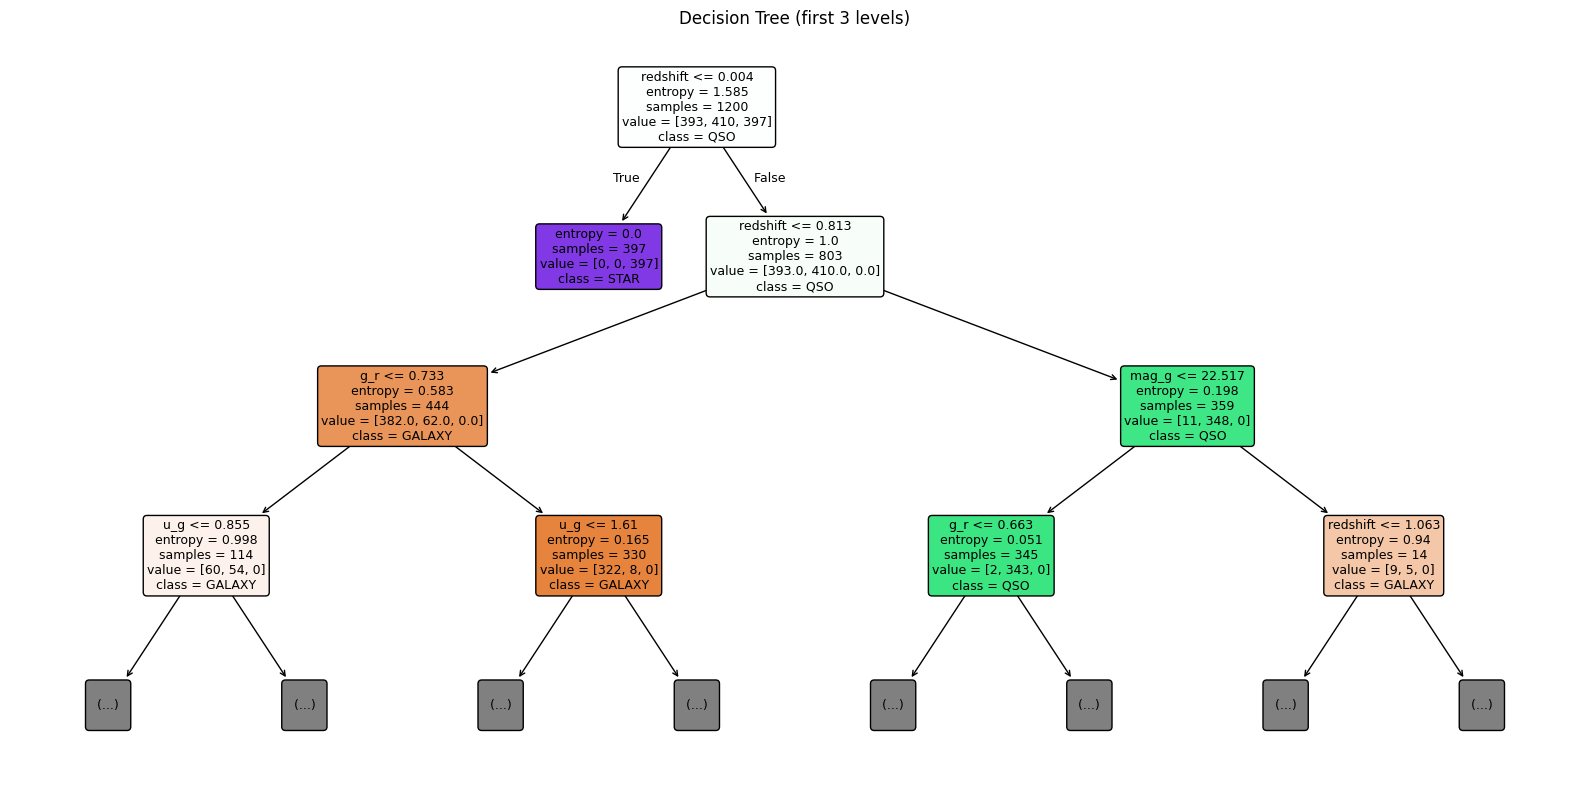

In [5]:
# Tree Visiualization
plt.figure(figsize = (16, 8))
feature_columns = X_feat.columns.to_list()
plot_tree(dec_tree, 
          feature_names = feature_columns, 
          class_names = dec_tree.classes_,
          filled = True, 
          rounded = True, 
          max_depth = 3,
          fontsize = 9)
plt.title("Decision Tree (first 3 levels)")
plt.tight_layout()
plt.show()

## Depth vs Accuracy  
 

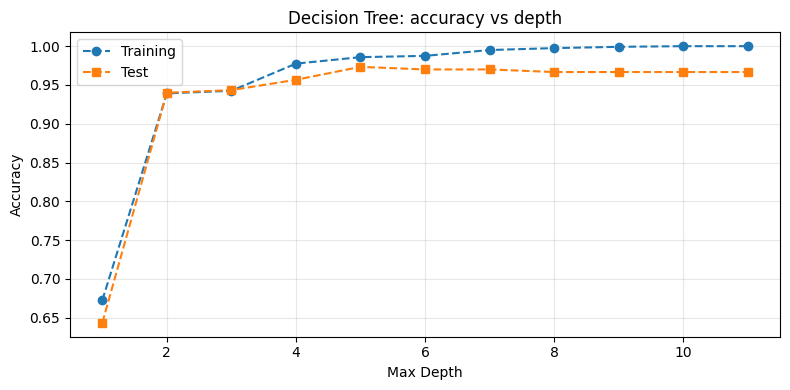

Best depth: 5 (test accuracy: 0.973)


In [6]:
train_acc, test_acc = [], []
depths = range(1, 12)

for depth in depths:
    tree = DecisionTreeClassifier(max_depth  = depth, 
                                  criterion = "entropy",
                                  random_state = RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    test_acc.append(tree.score(X_test, y_test))

plt.figure(figsize = (8, 4))
plt.plot(depths, train_acc, "o--", label = "Training")
plt.plot(depths, test_acc, "s--", label = "Test")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: accuracy vs depth")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmax(test_acc))]
print(f"Best depth: {best_depth} (test accuracy: {max(test_acc):.3f})")

## Step 3: Random Forest  
  

In [7]:
estimators = [50, 100, 200]
for estim in estimators:
    
    rand_forest = RandomForestClassifier(n_estimators = estim, 
                                        random_state = RANDOM_STATE)
    rand_forest.fit(X_train, y_train)
    y_pred_rand_forest = rand_forest.predict(X_test)

    acc_rand_forest = accuracy_score(y_test, y_pred_rand_forest)
    print("-" * 54)
    print(f"Random Forest Accuracy: {acc_rand_forest:.3f}, Num estimators: {estim}")
    print(f"\nClassification Report")
    print(classification_report(y_test, 
                                y_pred_rand_forest, 
                                target_names = rand_forest.classes_))

------------------------------------------------------
Random Forest Accuracy: 0.977, Num estimators: 50

Classification Report
              precision    recall  f1-score   support

      GALAXY       0.97      0.96      0.97       107
         QSO       0.96      0.97      0.96        90
        STAR       1.00      1.00      1.00       103

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

------------------------------------------------------
Random Forest Accuracy: 0.980, Num estimators: 100

Classification Report
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97       107
         QSO       0.97      0.97      0.97        90
        STAR       1.00      1.00      1.00       103

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98   

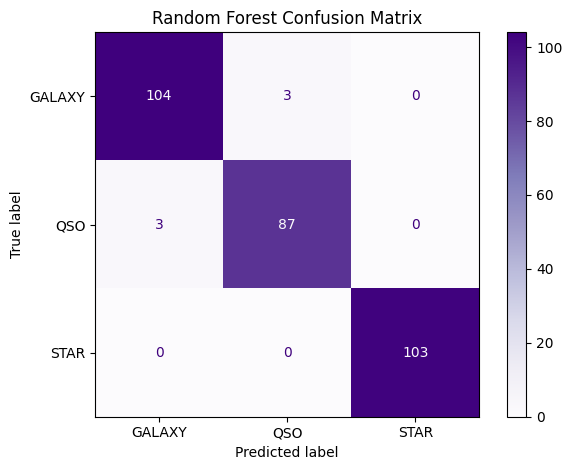

In [8]:
ConfusionMatrixDisplay.from_estimator(rand_forest, X_test, y_test, cmap="Purples")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

Step 4: Feature Importance  
  

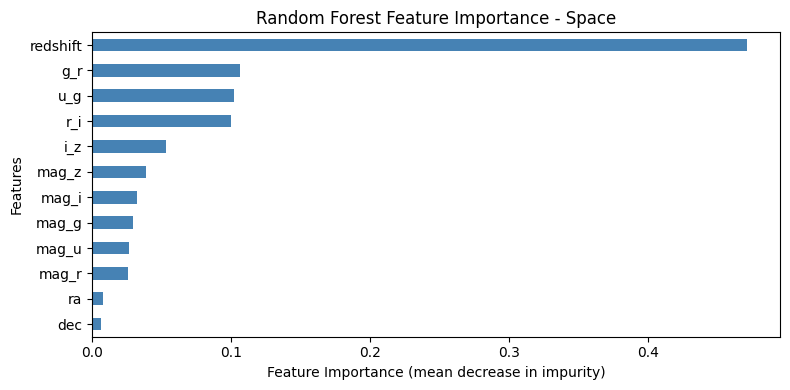


Feature Importance Ranking:
  redshift: 0.471
  g_r: 0.106
  u_g: 0.102
  r_i: 0.100
  i_z: 0.053
  mag_z: 0.039
  mag_i: 0.033
  mag_g: 0.029
  mag_u: 0.026
  mag_r: 0.026
  ra: 0.008
  dec: 0.007


In [9]:
importance = pd.Series(rand_forest.feature_importances_, index = feature_columns)
importance = importance.sort_values(ascending = True)

plt.figure(figsize = (8, 4))
importance.plot(kind = "barh", color = "steelblue")
plt.xlabel("Feature Importance (mean decrease in impurity)")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance - Space")
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for feature, importance in importance.sort_values(ascending = False).items():
    print(f"  {feature}: {importance:.3f}")

## Step 5: Model comparison  
  

In [10]:
scaler = StandardScaler()

all_models = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Logistic Reg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=best_depth,
                                            criterion="entropy",
                                            random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
}

print(f"{'Model':<20} {'CV Mean':>10} {'CV Std':>10}") 
print("-" * 42)
for name, model in all_models.items():
    use_scaled = name in ["KNN (k=5)", "Logistic Reg", "Naive Bayes"]
    data = scaler.fit_transform(X_feat) if use_scaled else X_feat
    scores = cross_val_score(model, data, y_target, cv = 5)
    print(f"{name:<20} {scores.mean():>10.3f} {scores.std():>10.3f}")

Model                   CV Mean     CV Std
------------------------------------------
KNN (k=5)                 0.866      0.017
Logistic Reg              0.930      0.010
Naive Bayes               0.952      0.015
Decision Tree             0.967      0.011
Random Forest             0.978      0.007


## Discussion  
  
- Increasing the number of estimators did provide a small improvement in accuracy, 
  however, when looking at other metrics like precision, recall, and f1-score, there 
  was no significant difference in accuracy, if any at all.  
- The best depth for overall accuracy was 5, but again, the differences were negligible.  
- Overall, random forest out-performed the other models (without fine tuning those models).  
- It was also clear that redshift is by far the feature with the most importance, 
  which is generally not surprising because it is difficult to visually classify 
  objects in this dataset by color bands alone.